<a href="https://colab.research.google.com/github/Terrypepra/Adshield-project/blob/main/notification_spam_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv(
    "SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
print(df.shape)
print(df.head())


(5572, 2)
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [4]:
df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

print(df["label"].value_counts())

label
0    4825
1     747
Name: count, dtype: int64


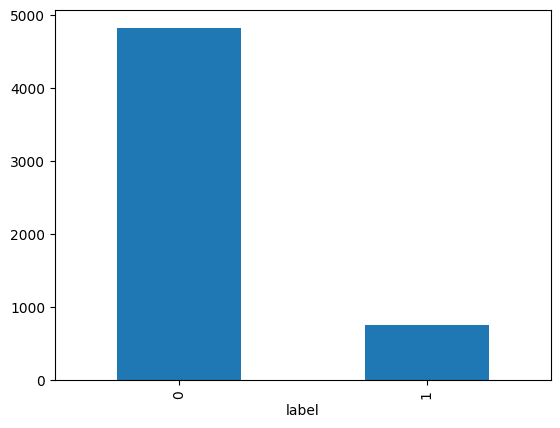

In [5]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")

plt.show()

In [7]:
from sklearn.model_selection import train_test_split

X = df["message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
df.shape


(5572, 2)

In [10]:
from sklearn.model_selection import train_test_split

X = df["message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4457
Testing samples: 1115


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training matrix shape:", X_train_tfidf.shape)

Training matrix shape: (4457, 5000)


In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

print("Training complete!")

Training complete!


In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

predictions = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

Accuracy : 0.9704035874439462
Precision: 1.0
Recall   : 0.7785234899328859
F1 Score : 0.8754716981132076

Confusion Matrix:
[[966   0]
 [ 33 116]]


In [14]:
import joblib

joblib.dump(model, "notification_spam_model.joblib")
joblib.dump(vectorizer, "notification_vectorizer.joblib")

['notification_vectorizer.joblib']